In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

print("seaborn:", sns.__version__)

seaborn: 0.13.2


In [ ]:
df = sns.load_dataset('titanic')
print(df.shape)
print(df.head())

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


/var/folders/j3/2yy7s8z57tl78m366kkwbdqr0000gn/T/ipykernel_75445/132041818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='coolwarm')
/var/folders/j3/2yy7s8z57tl78m366kkwbdqr0000gn/T/ipykernel_75445/132041818.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pclass', y='age', ax=axes[1], palette='Set2')


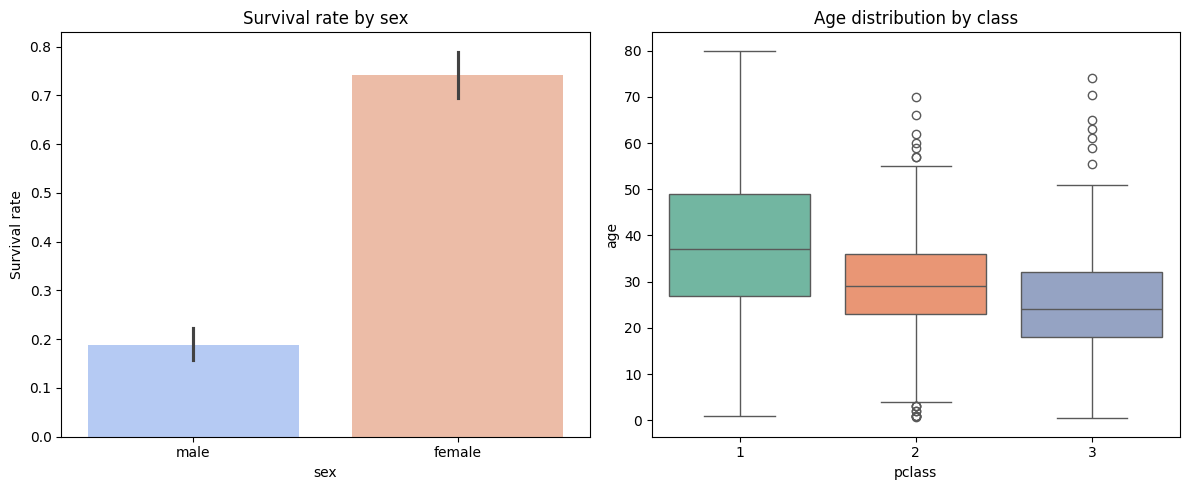

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: выживаемость по полу 
sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='coolwarm')
axes[0].set_title('Survival rate by sex')
axes[0].set_ylabel('Survival rate')

# График 2: распределение возраста по классу
sns.boxplot(data=df, x='pclass', y='age', ax=axes[1], palette='Set2')
axes[1].set_title('Age distribution by class')

plt.tight_layout()
plt.show()

/var/folders/j3/2yy7s8z57tl78m366kkwbdqr0000gn/T/ipykernel_75445/1406417754.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pclass', y='fare', ax=axes[1], palette='Set2')


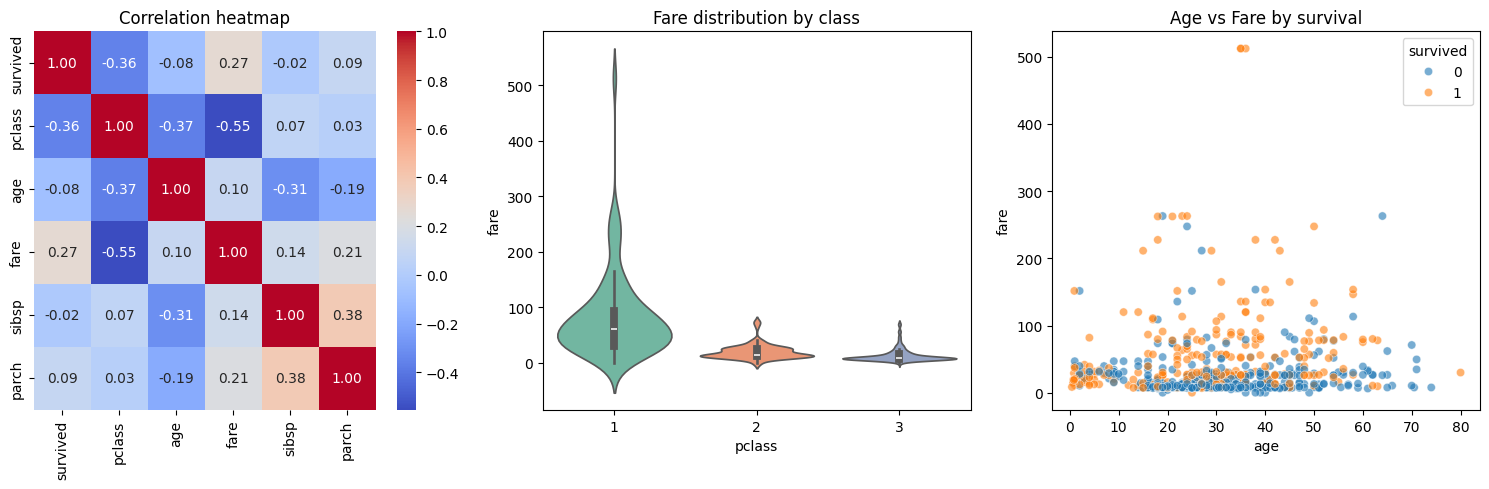

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: heatmap корреляций
numeric_cols = df[['survived', 'pclass', 'age', 'fare', 'sibsp', 'parch']].dropna()
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation heatmap')

# График 2: violin plot распределения стоимости билетов по классам
sns.violinplot(data=df, x='pclass', y='fare', ax=axes[1], palette='Set2')
axes[1].set_title('Fare distribution by class')

# График 3: scatter plot с цветом по выживаемости
sns.scatterplot(data=df, x='age', y='fare', 
                hue='survived', ax=axes[2], alpha=0.6)
axes[2].set_title('Age vs Fare by survival')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
print("plotly imported")

plotly imported


In [9]:
fig = px.bar(
    df.groupby('sex')['survived'].mean().reset_index(),
    x='sex',
    y='survived',
    color='sex',
    title='Survival rate by sex',
    labels={'survived': 'Survival rate'}
)
fig.show()

In [10]:
# График 1: scatter plot интерактивный
fig1 = px.scatter(
    df, x='age', y='fare',
    color='survived',
    size='fare',
    hover_data=['sex', 'pclass'],
    title='Age vs Fare — hover to see details',
    labels={'survived': 'Survived'}
)
fig1.show()

In [12]:
# График 2: sunburst — иерархическая визуализация
fig2 = px.sunburst(
    df.dropna(subset=['age']),
    path=['pclass', 'sex', 'survived'],
    title='Survival hierarchy: class → sex → survived'
)
fig2.show()

In [13]:
# График 3: histogram с группировкой
fig3 = px.histogram(
    df, x='age',
    color='survived',
    nbins=30,
    barmode='overlay',
    opacity=0.7,
    title='Age distribution by survival'
)
fig3.show()